This tutorial demonstrates how to use DECONVersation to run and evaluate deconvolution on pseudobulk data, using built-in pseudobulk simulation functions available within the package. scVI embeddings are used throughout, though the workflow is fully adaptable to Cell2Sentence , scGPT or CellHermes. The tutorial covers the full pipeline: generating pseudobulk data, constructing signature matrices, extracting Geneformer embeddings from both the pseudobulk and single-cell reference signature datasets, and estimating cell type proportions via NNLS. Predicted proportions are then evaluated against ground truth using RMSE and Pearson correlation to benchmark deconvolution performance. <br>

<b> scvi-human-2024-07-01 </b> <br>The scVI model is trained on non-spatial, human RNA sequencing data from the CZ CELLxGENE Discover Census, version 2024-07-01 (74.3M cells).

In [1]:
# Append path to deconversation modules
import sys
import os
import scanpy as sc
sys.path.append('../deconversation')

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Import associated modules
from pseudobulk import *
from preprocessing import *

In [4]:
# Path to single-cell RNAseq data 
path = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/hao800_id.h5ad"

In [5]:
# Read the h5ad file (just to explore columns and variables)
adata = sc.read_h5ad(path)

# Subset to select cell types
adata = adata[adata.obs["broad_type"].isin(['B cells', 'Monocytes', 'NK cells', 'T cells'])]
adata = adata.copy()

# Remove unmapped genes
adata = adata[:, adata.var.index.notnull()]

# Prep data for geneformer 
#adata = load_and_prep_data(adata= adata, cell_type_col= "broad_type", mode="geneformer")

### Step 2: Create pseudobulk

In [12]:
# Create pseudobulk and cell type prortions (ground truth)
pseudo_bulk, cell_prop = generate_pseudobulk(adata = adata,
                                             cell_type_col = "broad_type", # cell type column
                                             n_pseudobulks = 500, # Number of pseudobulk samples to be created
                                             target_proportion_min = 0.1, # expected min cell type proportion
                                             target_proportion_max = 0.80, # expected max cell type proportion
                                             n_cells_per_pseudobulk = 300, # number of cells to be used for pseudobulking per sample
                                             random_state = 42 # random state for reproducibility
                                            )

### Step 3: Create signature matrix

In [13]:
# Create signature matrix from single cell data
sig_mat = create_signature_matrix(adata = adata,
                                  sample_col = "batch", # sample id column
                                  celltype_col = "broad_type",
                                  groupby = "broad_type",
                                  sample_ids = None,
                                  output_path = None)

# Transpose for embedding extraction
# Columns should be gene names or ensembl ids (ensembl ids for geneformer)
sig_mat = sig_mat.T

### Step 4: Extract scVI Embeddings

In [8]:
from embeddings import *

geneformer is not installed. Skipping related functions.
cell2sentence is not installed. Skipping related functions.
cellhermes is not installed. Skipping related functions.
scGPT successfully imported.
scVI successfully imported.


<b> scvi-human-2024-07-01 </b> <br>The scVI model is trained on non-spatial, human RNA sequencing data from the CZ CELLxGENE Discover Census, version 2024-07-01 (74.3M cells).

In [14]:
sig_mat_scvi_embed = extract_embs(
    bulk_df = sig_mat, # sample x ensembl id
    mode = "scvi", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01", 
    delete_temp_files = True
)

INFO     File /gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01/model.pt already downloaded  
INFO     Found 44.262499999999996% reference vars in query data.                                                   
INFO     File /gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01/model.pt already downloaded  


In [15]:
pseudo_bulk_embed = extract_embs(
    bulk_df = pseudo_bulk, # sample x ensembl id
    mode = "scvi", 
    temp_output_dir = "/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/", 
    model_path= "/gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01", 
    delete_temp_files = True
)

INFO     File /gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01/model.pt already downloaded  
INFO     Found 44.262499999999996% reference vars in query data.                                                   
INFO     File /gpfs/commons/groups/compbio/projects/ao_projects/scvi-human-2024-07-01/model.pt already downloaded  


### Step 5: Run Non-Negative Least Squares (NNLS)

In [16]:
from deconvolution import *

In [17]:
# Run NNLS
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk_embed.T, #columns should be embedding dimensions
                            signature_df = sig_mat_scvi_embed.T, #columns should be embedding dimensions
                            normalize = True)

Using 50 common features.
Running deconvolution...


In [18]:
cell_prop_pred.to_csv("../outputs/scVI_estimated_proportions.csv")

### Step 6: Evaluate estimated proportions

In [19]:
from evaluation import *

In [20]:
#Compute RMSE per cell type
rmse_per_cell_type = compute_rmse(true_df = cell_prop, # sample (rows) x cell type (columns)
                                 pred_df = cell_prop_pred, # sample (rows) x cell type (columns)
                                 return_per_celltype = True)

rmse_per_cell_type = pd.DataFrame(rmse_per_cell_type)

rmse_per_cell_type

,overall,per_celltype
NK cells,0.21661,0.137120
T cells,0.21661,0.306933
Monocytes,0.21661,0.230923
B cells,0.21661,0.146096


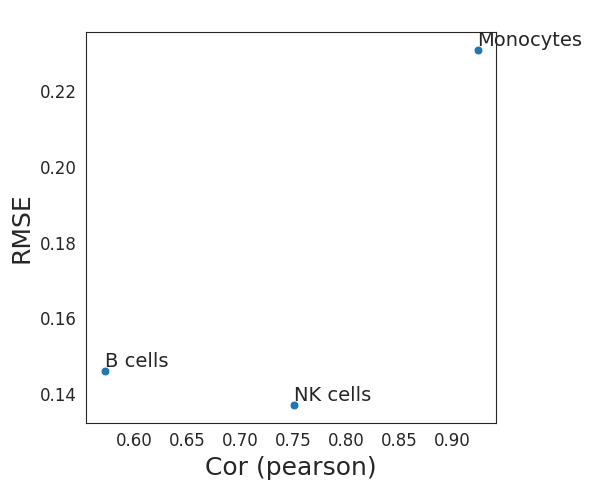

In [21]:
# Visualize RMSE - Correlation plot
# Both RMSE and Correlation coefficients are overall values (i.e not stratified by cell type)
sns.set_style("white")
plot_rmse_vs_corr_by_celltype(
    true_df = cell_prop,
    pred_df = cell_prop_pred
)

In [24]:
from visualization import *

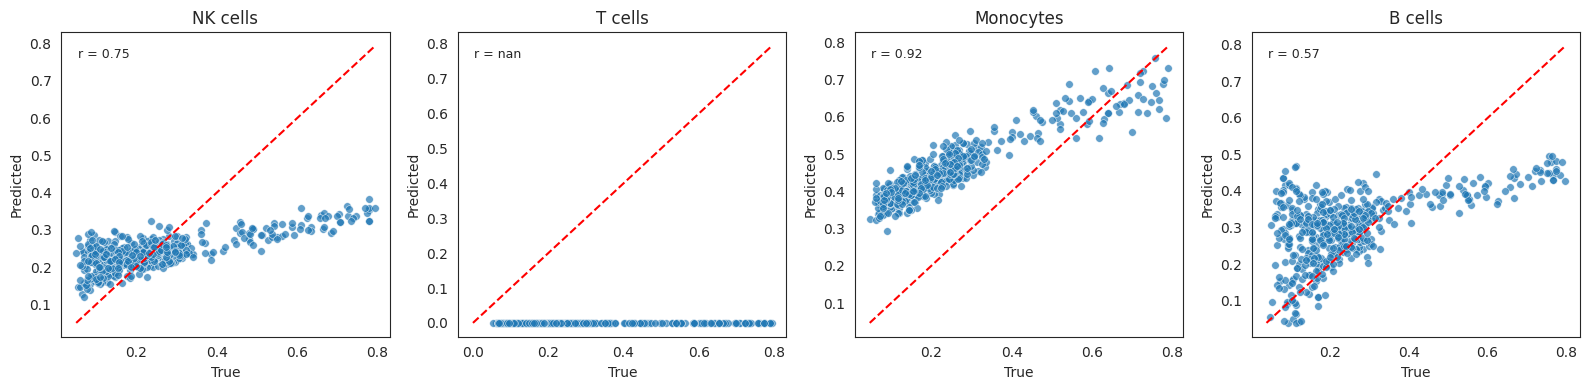

In [25]:
plot_true_vs_predicted(
    y_true_df = cell_prop, # sample (rows) x cell type (columns)
    y_pred_df = cell_prop_pred, # sample (rows) x cell type (columns)
    stratify_by_celltype= True,
    dot_size = 30,n_cols=4,
    figsize_per_plot = (4,4)
    
)

Using 50 common features.
Running deconvolution...


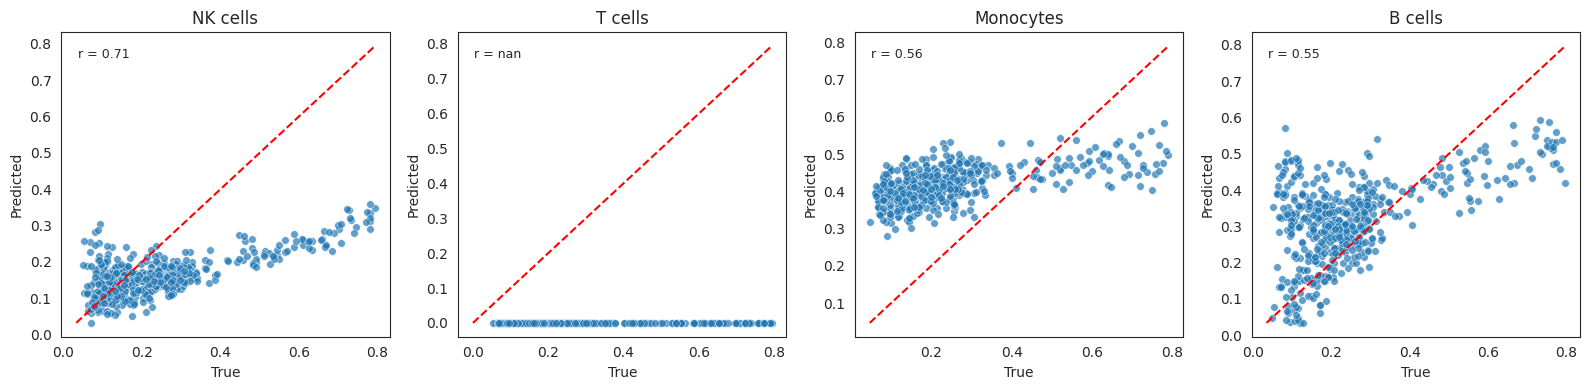

In [27]:
# Run ridge
cell_prop_pred = run_deconv(bulk_df = pseudo_bulk_embed.T,
                            signature_df = sig_mat_scvi_embed.T, 
                            solver= "ridge",
                            normalize = True)

# Visualize 
plot_true_vs_predicted(
    y_true_df = cell_prop,
    y_pred_df = cell_prop_pred,
    stratify_by_celltype = True, 
    dot_size = 30,n_cols=4,
    figsize_per_plot = (4,4)
)